# Wagner Leitmotif Pattern Recognition

- **10 Wagner leitmotifs** (Ring, Sword, Ride of the Valkyries, Forest Murmurs, etc.)
- **70 film composer scores** across 5 composers: Morricone, Korngold, Shore, Williams, Steiner 

- Multi-dimensional combined scoring (interval 50% + contour 30% + rhythm 20%)
- Adaptive thresholds — shorter patterns need stronger multi-dimensional evidence
- Unified sliding-window scorer classifies every window position
- Statistical significance test (to avoid expected random matches)
- top_n=10 with combined-score ranking
- Rhythm similarity integrated into the combined score
- Normalised density accounting for pattern length and score size

### inspired Methodology (Janssen et al. 2013)

- Exact match: Interval sliding window but classified via unified scorer
- Approximate match:  Levenshtein with scaled max-distance
- Contour match: Folded into combined score (pure contour suppressed to avoid false positives)
- Combined score: 0.50 interval + 0.30 contour + 0.20 rhythm

### Musicological Hypothesis

| Composer | Known Wagner Influence | Expected Leitmotif Density |
|---|---|---|
| Korngold | Very High (direct lineage) | High |
| Steiner | High (Golden Age Hollywood) | Medium-High |
| Williams | Medium-High (neo-Romantic) | Medium |
| Shore | High (LOTR explicitly Wagnerian) | High |
| Morricone | Low-Medium (idiosyncratic style) | Low |


In [1]:
# Cell 01 — Imports
import os
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from music21 import converter, interval, stream, note, chord, duration, metadata
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print("All imports successful.")
import music21
print(f"music21 version: {music21.__version__}")


All imports successful.
music21 version: 9.9.1


In [2]:
# Cell 02 — Configure real data paths
NOTEBOOK_DIR = Path(os.path.abspath(''))
LEIT_DIR = str(NOTEBOOK_DIR / 'leitmotifs')
SCORE_DIR = str(NOTEBOOK_DIR / 'scores')
OUTPUT_DIR = str(NOTEBOOK_DIR / 'output')

COMPOSER_NAMES = ['ennio_morricone', 'erich_wolfgang_korngold', 'howard_shore',
                  'john_williams', 'max_steiner']

# Verify data exists
leit_files = sorted(Path(LEIT_DIR).glob('*.musicxml'))
print(f"Leitmotif directory: {LEIT_DIR}")
print(f"  Found {len(leit_files)} leitmotif files:")
for f in leit_files:
    print(f"    - {f.name}")

print(f"\nScore directory: {SCORE_DIR}")
total_scores = 0
for cdir in sorted(Path(SCORE_DIR).iterdir()):
    if cdir.is_dir():
        scores = list(cdir.glob('*.musicxml'))
        total_scores += len(scores)
        print(f"  {cdir.name}: {len(scores)} scores")
print(f"  Total: {total_scores} scores")


Leitmotif directory: /Users/yalu/symbolic-motif-search/leitmotifs
  Found 10 leitmotif files:
    - ForestMurmurs_motif.musicxml
    - Horn_motif.musicxml
    - Mime_motif.musicxml
    - NibelungsHate_motif.musicxml
    - Nibelungs_motif.musicxml
    - Ride_motif.musicxml
    - Ring_motif.musicxml
    - SiblingsLove_motif.musicxml
    - SwirlingBlaze_motif.musicxml
    - Sword_motif.musicxml

Score directory: /Users/yalu/symbolic-motif-search/scores
  ennio_morricone: 19 scores
  erich_wolfgang_korngold: 13 scores
  howard_shore: 8 scores
  john_williams: 15 scores
  max_steiner: 15 scores
  Total: 70 scores


## Section 1 — Music Representation

Following Janssen et al. (2013), we extract multiple parallel representations:

| Representation | Description | Property |
|---|---|---|
| MIDI pitch | Absolute pitch as MIDI number | Pitch-specific |
| Interval | Semitone distance between consecutive notes | **Transposition-invariant** |
| Contour | Direction only: -1, 0, +1 | **Shape-based** |
| Rhythm | Duration in quarter-note units | Time-domain |
| Combined | (interval, rhythm) tuples | Multi-dimensional |


In [3]:
# Cell 04 — extract_representations()

def extract_representations(path):
    # Extract multiple music representations from a MusicXML file.
    # Returns dict with keys: midi, interval, contour, rhythm, combined, notes, path
    score = converter.parse(path)
    part = score.parts[0].flatten()

    notes_list = []
    for el in part.notesAndRests:
        if isinstance(el, note.Note):
            notes_list.append(el)
        elif isinstance(el, chord.Chord):
            top_note = note.Note(el.pitches[-1])
            top_note.duration = el.duration
            notes_list.append(top_note)

    if len(notes_list) < 2:
        raise ValueError(f"Too few notes in {path}")

    midi_seq = [n.pitch.midi for n in notes_list]

    interval_seq = []
    for i in range(len(notes_list) - 1):
        try:
            iv = interval.Interval(noteStart=notes_list[i], noteEnd=notes_list[i+1])
            interval_seq.append(iv.semitones)
        except Exception:
            interval_seq.append(midi_seq[i+1] - midi_seq[i])

    contour_seq = [
        0 if interval_seq[i] == 0 else (1 if interval_seq[i] > 0 else -1)
        for i in range(len(interval_seq))
    ]

    rhythm_seq = [float(n.duration.quarterLength) for n in notes_list]
    combined_seq = list(zip(interval_seq, rhythm_seq[:-1]))

    return {
        'midi': midi_seq,
        'interval': interval_seq,
        'contour': contour_seq,
        'rhythm': rhythm_seq,
        'combined': combined_seq,
        'notes': notes_list,
        'path': path
    }

# Demo: extract representations from the Sword motif
demo_path = os.path.join(LEIT_DIR, 'Sword_motif.musicxml')
demo_repr = extract_representations(demo_path)
print(f"Leitmotif: Sword_motif")
print(f"  MIDI pitches : {demo_repr['midi']}")
print(f"  Intervals    : {demo_repr['interval']}")
print(f"  Contour      : {demo_repr['contour']}")
print(f"  Rhythm       : {demo_repr['rhythm']}")
print(f"  Combined     : {demo_repr['combined']}")


Leitmotif: Sword_motif
  MIDI pitches : [67, 72, 60, 64, 67, 72, 76]
  Intervals    : [5, -12, 4, 3, 5, 4]
  Contour      : [1, -1, 1, 1, 1, 1]
  Rhythm       : [0.5, 2.0, 1.75, 0.25, 1.5, 0.5, 2.0]
  Combined     : [(5, 0.5), (-12, 2.0), (4, 1.75), (3, 0.25), (5, 1.5), (4, 0.5)]


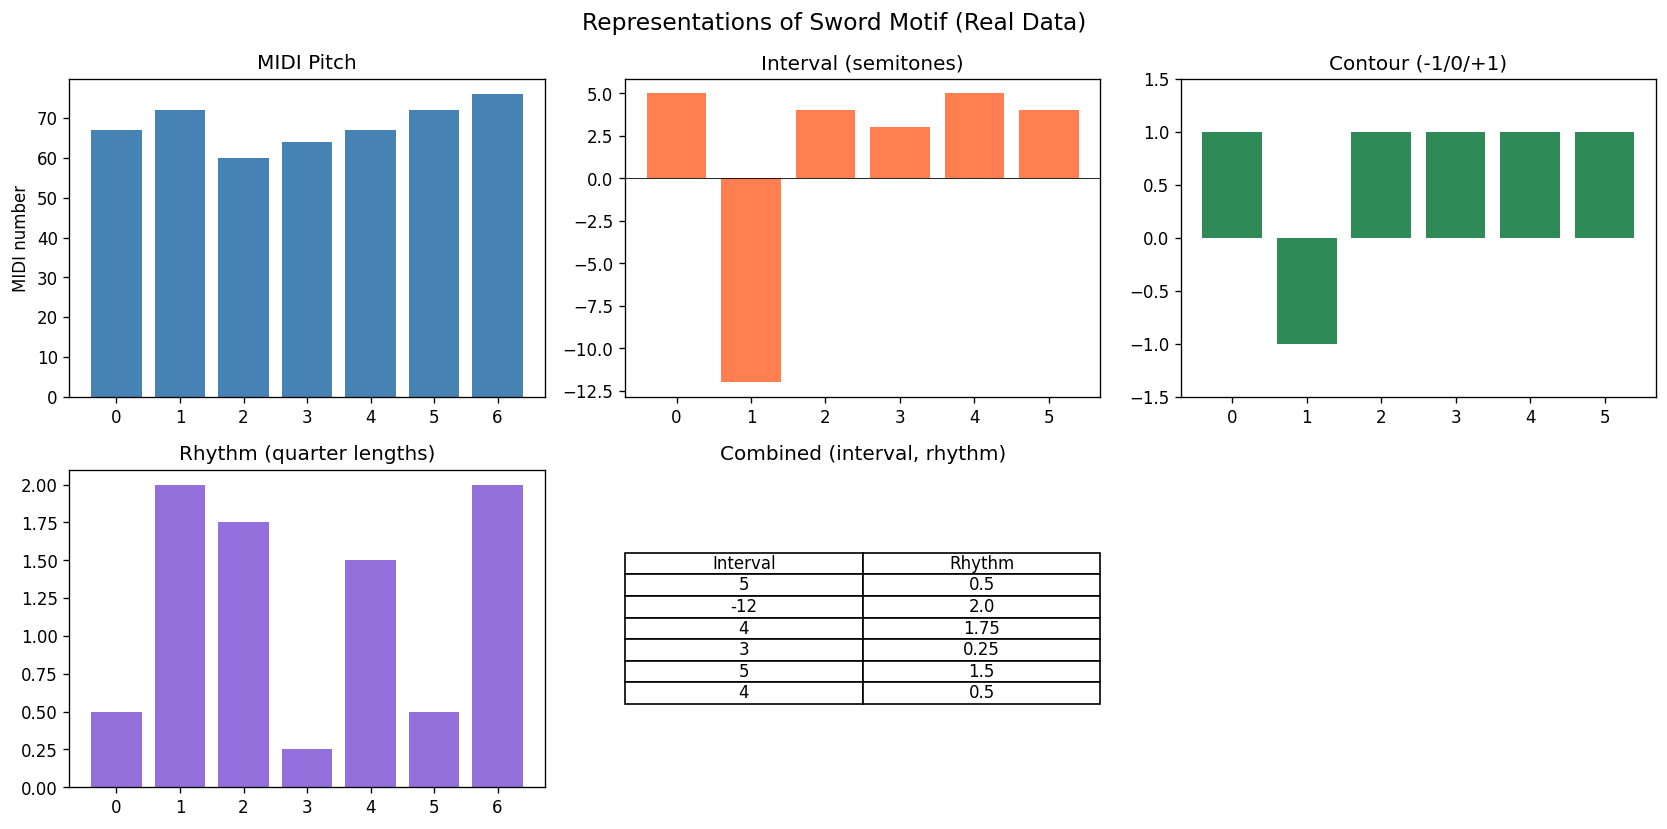

Representation  Length                               Sample
          midi       7                  [67, 72, 60, 64]...
      interval       6                    [5, -12, 4, 3]...
       contour       6                     [1, -1, 1, 1]...
        rhythm       7            [0.5, 2.0, 1.75, 0.25]...
      combined       6 [(5, 0.5), (-12, 2.0), (4, 1.75)]...


In [4]:
# Cell 05 — Visualise all 5 representations of the Sword motif

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Representations of Sword Motif (Real Data)', fontsize=14)

axes[0,0].bar(range(len(demo_repr['midi'])), demo_repr['midi'], color='steelblue')
axes[0,0].set_title('MIDI Pitch')
axes[0,0].set_ylabel('MIDI number')

axes[0,1].bar(range(len(demo_repr['interval'])), demo_repr['interval'], color='coral')
axes[0,1].set_title('Interval (semitones)')
axes[0,1].axhline(0, color='black', linewidth=0.5)

axes[0,2].bar(range(len(demo_repr['contour'])), demo_repr['contour'], color='seagreen')
axes[0,2].set_title('Contour (-1/0/+1)')
axes[0,2].set_ylim(-1.5, 1.5)

axes[1,0].bar(range(len(demo_repr['rhythm'])), demo_repr['rhythm'], color='mediumpurple')
axes[1,0].set_title('Rhythm (quarter lengths)')

axes[1,1].axis('off')
table_data = [[f"{iv}", f"{r}"] for iv, r in demo_repr['combined']]
table = axes[1,1].table(cellText=table_data, colLabels=['Interval', 'Rhythm'],
                         loc='center', cellLoc='center')
table.auto_set_font_size(True)
axes[1,1].set_title('Combined (interval, rhythm)')

axes[1,2].axis('off')

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Representation': ['midi', 'interval', 'contour', 'rhythm', 'combined'],
    'Length': [len(demo_repr['midi']), len(demo_repr['interval']),
               len(demo_repr['contour']), len(demo_repr['rhythm']),
               len(demo_repr['combined'])],
    'Sample': [str(demo_repr['midi'][:4])+'...', str(demo_repr['interval'][:4])+'...',
               str(demo_repr['contour'][:4])+'...', str(demo_repr['rhythm'][:4])+'...',
               str(demo_repr['combined'][:3])+'...']
})
print(summary.to_string(index=False))


In [5]:
# Cell 06 — Load ALL leitmotifs and display summary with sizes

leitmotif_reprs = {}
rows = []
for lf in sorted(Path(LEIT_DIR).glob('*.musicxml')):
    try:
        r = extract_representations(str(lf))
        leitmotif_reprs[lf.stem] = r
        n_notes = len(r['midi'])
        n_iv = len(r['interval'])
        rows.append({
            'Leitmotif': lf.stem,
            'Notes': n_notes,
            'Intervals': n_iv,
            'Contour': str(r['contour']),
            'Interval_seq': str(r['interval'])
        })
    except Exception as e:
        print(f"  x {lf.stem}: {e}")

print(f"Successfully loaded {len(leitmotif_reprs)} / {len(leit_files)} leitmotifs\n")

# Summary table sorted by interval count
leit_summary = pd.DataFrame(rows).sort_values('Intervals')
print("=== Leitmotif Size Summary ===")
print(leit_summary[['Leitmotif', 'Notes', 'Intervals']].to_string(index=False))

# Flag short motifs
short_motifs = leit_summary[leit_summary['Intervals'] <= 5]['Leitmotif'].tolist()
print(f"\nShort motifs (<=5 intervals): {short_motifs}")
print("These require higher combined-score thresholds to avoid false positives.")


Successfully loaded 10 / 10 leitmotifs

=== Leitmotif Size Summary ===
          Leitmotif  Notes  Intervals
         Mime_motif      4          3
         Ride_motif      6          5
SwirlingBlaze_motif      6          5
 SiblingsLove_motif      7          6
        Sword_motif      7          6
         Ring_motif      8          7
    Nibelungs_motif      9          8
         Horn_motif     11         10
NibelungsHate_motif     13         12
ForestMurmurs_motif     48         47

Short motifs (<=5 intervals): ['Mime_motif', 'Ride_motif', 'SwirlingBlaze_motif']
These require higher combined-score thresholds to avoid false positives.


## Section 2 — Improved Multi-Dimensional Matching

### Problem with v1
In v1, three independent matchers (exact, approximate, contour) each produced separate match lists.
**99.7% of all matches were contour-only** — matching generic melodic directions like "up-down-up"
that occur randomly in any tonal music. The `combined` representation (interval + rhythm) was extracted
but never used for matching.

### Solution: Unified Combined Scorer
For every sliding-window position, we now compute **three similarity dimensions simultaneously**
and combine them into a single score:

**combined_score = 0.50 x S_interval + 0.30 x S_contour + 0.20 x S_rhythm**

where:
- S_interval = fraction of exactly matching chromatic intervals (transposition-invariant)
- S_contour = fraction of matching melodic directions (-1/0/+1)
- S_rhythm = fraction of note durations within a 2:1 ratio

### Adaptive Thresholds

Instead of a fixed min_similarity = 0.80 for all motifs, the threshold adapts to pattern length:

| Intervals | Threshold | Rationale |
|---|---|---|
| <= 3 (Mime) | 0.70 | Very short: pure contour (max ~ 0.46) is suppressed; needs interval evidence |
| 4-6 (Ride, Sword, etc.) | 0.60 | Short: combined score requires partial interval match |
| 7-10 (Ring, Horn, etc.) | 0.55 | Medium: moderate threshold still filters noise |
| 11-15 (NibelungsHate) | 0.50 | Longer: patterns are inherently more selective |
| > 15 (ForestMurmurs) | 0.45 | Very long: even moderate combined evidence is significant |

**Key insight**: A pure contour match with good rhythm scores at most ~ 0.46 (0.30 + 0.16),
which is **below all thresholds except the very longest patterns**. This eliminates the
contour-only noise that dominated v1 while still allowing every motif to be detected
if sufficient multi-dimensional evidence exists.

### Match Classification

| Class | Criteria | Confidence |
|---|---|---|
| exact | S_interval = 1.0 | Highest — perfect transposition |
| near-exact | S_interval >= 0.70 | High — most intervals match |
| strong | combined >= threshold AND S_interval >= 0.30 | Medium-High |
| moderate | combined >= threshold | Medium |
| weak | below threshold | Filtered out |


In [6]:
# Cell 08 — Multi-dimensional scoring functions

# Weights for the combined score
W_INTERVAL = 0.50
W_CONTOUR  = 0.30
W_RHYTHM   = 0.20

def get_adaptive_threshold(n_intervals):
    # Return minimum combined_score threshold based on pattern length.
    # Shorter patterns need higher thresholds because their contour
    # patterns are more likely to match by chance.
    if n_intervals <= 3:
        return 0.70
    elif n_intervals <= 6:
        return 0.60
    elif n_intervals <= 10:
        return 0.55
    elif n_intervals <= 15:
        return 0.50
    else:
        return 0.45

def compute_window_score(pattern_repr, score_repr, start_idx):
    # Compute interval, contour, and rhythm similarity for one sliding window.
    # pattern_repr: dict from extract_representations (leitmotif)
    # score_repr: dict from extract_representations (score)
    # start_idx: start index into the score interval/contour sequences
    n = len(pattern_repr['interval'])

    # --- Interval similarity (transposition-invariant) ---
    p_iv = pattern_repr['interval']
    s_iv = score_repr['interval'][start_idx:start_idx + n]
    iv_matches = sum(1 for a, b in zip(p_iv, s_iv) if a == b)
    iv_sim = iv_matches / n

    # --- Contour similarity ---
    p_ct = pattern_repr['contour']
    s_ct = score_repr['contour'][start_idx:start_idx + n]
    ct_matches = sum(1 for a, b in zip(p_ct, s_ct) if a == b)
    ct_sim = ct_matches / n

    # --- Rhythm similarity (ratio-based, using starting-note durations) ---
    # Align with intervals: use rhythm of the note that starts each interval
    p_rh = pattern_repr['rhythm'][:-1]   # len = n
    s_rh = score_repr['rhythm'][start_idx:start_idx + n]
    rh_matches = 0
    for a, b in zip(p_rh, s_rh):
        if a > 0 and b > 0:
            ratio = min(a, b) / max(a, b)
            if ratio >= 0.5:   # within 2:1
                rh_matches += 1
        elif a == 0 and b == 0:
            rh_matches += 1
    rh_sim = rh_matches / n if n > 0 else 0.0

    # --- Combined score ---
    combined = W_INTERVAL * iv_sim + W_CONTOUR * ct_sim + W_RHYTHM * rh_sim

    # --- Classification ---
    if iv_sim == 1.0:
        match_class = 'exact'
    elif iv_sim >= 0.70:
        match_class = 'near-exact'
    elif combined >= get_adaptive_threshold(n) and iv_sim >= 0.30:
        match_class = 'strong'
    elif combined >= get_adaptive_threshold(n):
        match_class = 'moderate'
    else:
        match_class = 'weak'

    return {
        'interval_sim': round(iv_sim, 4),
        'contour_sim': round(ct_sim, 4),
        'rhythm_sim': round(rh_sim, 4),
        'combined_score': round(combined, 4),
        'match_class': match_class
    }


def find_unified_matches(pattern_repr, score_repr):
    # Sliding-window unified matcher: score every position,
    # keep those above adaptive threshold or with high interval similarity.
    n = len(pattern_repr['interval'])
    score_len = len(score_repr['interval'])
    threshold = get_adaptive_threshold(n)

    matches = []
    for i in range(score_len - n + 1):
        sc = compute_window_score(pattern_repr, score_repr, i)

        # Accept if combined score meets adaptive threshold OR interval sim is high
        if sc['combined_score'] >= threshold or sc['interval_sim'] >= 0.70:
            matches.append({
                'start_note_idx': i,
                'end_note_idx': i + n + 1,   # +1 because n intervals = n+1 notes
                'interval_sim': sc['interval_sim'],
                'contour_sim': sc['contour_sim'],
                'rhythm_sim': sc['rhythm_sim'],
                'combined_score': sc['combined_score'],
                'match_class': sc['match_class'],
            })

    return sorted(matches, key=lambda x: x['combined_score'], reverse=True)


# --- Levenshtein (kept for approximate interval matching) ---

def levenshtein_distance(seq1, seq2, max_dist=None):
    # Levenshtein distance with optional early termination.
    m, n = len(seq1), len(seq2)
    if max_dist is not None and abs(m - n) > max_dist:
        return max_dist + 1
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if seq1[i-1] == seq2[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
        if max_dist is not None and min(dp[i]) > max_dist:
            return max_dist + 1
    return dp[m][n]


def find_approximate_matches(pattern_repr, score_repr, max_distance=None):
    # Levenshtein-based approximate matching on interval sequences.
    # max_distance scales with pattern length: max(1, n_intervals // 4), capped at 3.
    # Skips windows already found as exact.
    pattern = pattern_repr['interval']
    text = score_repr['interval']
    n = len(pattern)
    if max_distance is None:
        max_distance = min(3, max(1, n // 4))
    if n > 25:
        return []   # too expensive for very long patterns

    matches = []
    for i in range(len(text) - n + 1):
        window = text[i:i + n]
        dist = levenshtein_distance(pattern, window, max_dist=max_distance)
        if 0 < dist <= max_distance:
            similarity = 1.0 - (dist / n)
            matches.append({
                'start_note_idx': i,
                'end_note_idx': i + n + 1,
                'match_class': 'approximate',
                'interval_sim': round(sum(1 for a, b in zip(pattern, window) if a == b) / n, 4),
                'contour_sim': round(sum(1 for a, b in zip(pattern_repr['contour'],
                    score_repr['contour'][i:i+n]) if a == b) / n, 4),
                'rhythm_sim': 0.0,
                'combined_score': round(similarity, 4),
                'edit_distance': dist,
            })
    return sorted(matches, key=lambda x: x['combined_score'], reverse=True)


print("All matching functions defined.")
print(f"   Weights: interval={W_INTERVAL}, contour={W_CONTOUR}, rhythm={W_RHYTHM}")
print(f"   Adaptive thresholds: {[(n, get_adaptive_threshold(n)) for n in [3,5,7,10,12,47]]}")


All matching functions defined.
   Weights: interval=0.5, contour=0.3, rhythm=0.2
   Adaptive thresholds: [(3, 0.7), (5, 0.6), (7, 0.55), (10, 0.55), (12, 0.5), (47, 0.45)]


In [7]:
# Cell 09 — Demo: Sword motif vs. Robin Hood Finale (v2 unified scorer)

demo_score_path = os.path.join(SCORE_DIR, 'erich_wolfgang_korngold',
                                'The Adventures of Robin Hood -  Finale.musicxml')
demo_score_repr = extract_representations(demo_score_path)
leit_repr = leitmotif_reprs['Sword_motif']

n_iv = len(leit_repr['interval'])
print(f"Score : Robin Hood Finale ({len(demo_score_repr['midi'])} notes)")
print(f"Motif : Sword_motif ({len(leit_repr['midi'])} notes, {n_iv} intervals)")
print(f"Adaptive threshold for {n_iv} intervals: {get_adaptive_threshold(n_iv)}")
print()

# Unified matching
unified = find_unified_matches(leit_repr, demo_score_repr)
print(f"Unified matches: {len(unified)}")
for m in unified[:10]:
    print(f"  idx {m['start_note_idx']:3d}-{m['end_note_idx']:3d}  "
          f"class={m['match_class']:12s}  "
          f"combined={m['combined_score']:.3f}  "
          f"iv={m['interval_sim']:.3f}  ct={m['contour_sim']:.3f}  rh={m['rhythm_sim']:.3f}")

# Approximate matching
approx = find_approximate_matches(leit_repr, demo_score_repr)
print(f"\nApproximate matches (Levenshtein): {len(approx)}")
for m in approx[:5]:
    print(f"  idx {m['start_note_idx']:3d}-{m['end_note_idx']:3d}  "
          f"edit_dist={m.get('edit_distance',0)}  combined={m['combined_score']:.3f}")

# Class breakdown
if unified:
    class_counts = pd.Series([m['match_class'] for m in unified]).value_counts()
    print(f"\nMatch class breakdown:")
    for cls, count in class_counts.items():
        print(f"  {cls}: {count}")


Score : Robin Hood Finale (857 notes)
Motif : Sword_motif (7 notes, 6 intervals)
Adaptive threshold for 6 intervals: 0.6

Unified matches: 1
  idx 608-615  class=strong        combined=0.650  iv=0.500  ct=1.000  rh=0.500

Approximate matches (Levenshtein): 0

Match class breakdown:
  strong: 1


## Section 3 — Statistical Significance

### Random Baseline

For a contour pattern of length n drawn from the alphabet {-1, 0, +1}, the probability
that a random window matches can be estimated.

For **interval matching**, the probability of an exact match at any window position
depends on the interval vocabulary size. Chromatic intervals in tonal music
span roughly [-12, +12] (25 values), so:

P(exact interval match) = (1/25)^n

- Mime (n=3): P ~ 6.4e-05 per window -> ~2.2 expected across all scores.
- Sword (n=6): P ~ 4.1e-09 per window -> essentially zero expected.

For **contour matching**, the alphabet is smaller (3 values), so random matches are far more likely:

P(exact contour match) = (1/3)^n

- Mime (n=3): P ~ 3.7% per window -> ~1,250 expected across all scores.
- Sword (n=6): P ~ 0.14% per window -> ~47 expected.

This confirms why pure contour matching dominated v1 results.

The **combined score** requires interval evidence, dramatically reducing the effective random match rate.


In [8]:
# Cell 11 — Compute random baseline for each leitmotif

print("=== Expected Random Matches (per score of ~500 notes) ===\n")
print(f"{'Leitmotif':30s} {'n':>4s} {'P(contour)':>12s} {'E[contour]':>12s} {'P(interval)':>14s} {'E[interval]':>14s}")
print('-' * 90)

avg_score_notes = 500
n_scores = 68

for name in sorted(leitmotif_reprs.keys()):
    n = len(leitmotif_reprs[name]['interval'])
    n_windows = avg_score_notes - n

    # Contour: 3-value alphabet
    p_contour = (1/3) ** n
    e_contour = p_contour * n_windows * n_scores

    # Interval: ~25-value effective alphabet
    p_interval = (1/25) ** n
    e_interval = p_interval * n_windows * n_scores

    print(f"{name:30s} {n:4d} {p_contour:12.6f} {e_contour:12.1f} {p_interval:14.2e} {e_interval:14.4f}")

print(f"\nConclusion: Pure contour matching produces ~1000+ random matches")
print(f"for short motifs -- confirming v1 3214 contour matches were largely noise.")
print(f"The combined score interval requirement (50% weight) suppresses this.")


=== Expected Random Matches (per score of ~500 notes) ===

Leitmotif                         n   P(contour)   E[contour]    P(interval)    E[interval]
------------------------------------------------------------------------------------------
ForestMurmurs_motif              47     0.000000          0.0       1.98e-66         0.0000
Horn_motif                       10     0.000017          0.6       1.05e-14         0.0000
Mime_motif                        3     0.037037       1251.7       6.40e-05         2.1629
NibelungsHate_motif              12     0.000002          0.1       1.68e-17         0.0000
Nibelungs_motif                   8     0.000152          5.1       6.55e-12         0.0000
Ride_motif                        5     0.004115        138.5       1.02e-07         0.0034
Ring_motif                        7     0.000457         15.3       1.64e-10         0.0000
SiblingsLove_motif                6     0.001372         46.1       4.10e-09         0.0001
SwirlingBlaze_motif   

## Section 4 — Filtering

Filtering applies:
1. **Adaptive combined-score threshold** (already applied in `find_unified_matches`)
2. **Non-overlapping windows**: keep highest-scoring match when windows overlap
3. **Top-N cap**: max 10 per (motif, score) pair (reduced from 20 in v1)
4. **Deduplication**: merge unified and approximate matches, prefer the one with higher combined_score


In [9]:
# Cell 13 — filter_matches() + merge

def filter_matches(matches, top_n=10):
    # Filter matches: remove overlaps, return top N by combined_score.
    # Matches are assumed to already pass the adaptive threshold.
    if not matches:
        return []

    filtered = sorted(matches, key=lambda x: x['combined_score'], reverse=True)

    # Remove overlapping windows -- keep highest score
    non_overlapping = []
    used_ranges = []
    for match in filtered:
        start, end = match['start_note_idx'], match['end_note_idx']
        overlap = any(not (end <= r[0] or start >= r[1]) for r in used_ranges)
        if not overlap:
            non_overlapping.append(match)
            used_ranges.append((start, end))

    return non_overlapping[:top_n]


def merge_match_lists(*match_lists):
    # Merge multiple match lists, deduplicating by start position.
    by_start = {}
    for mlist in match_lists:
        for m in mlist:
            key = m['start_note_idx']
            if key not in by_start or m['combined_score'] > by_start[key]['combined_score']:
                by_start[key] = m
    return list(by_start.values())


# Demo: filter Sword vs Robin Hood results
all_matches = merge_match_lists(unified, approx)
filtered = filter_matches(all_matches)
print(f"Before filtering: {len(all_matches)} matches")
print(f"After filtering:  {len(filtered)} matches")
for m in filtered[:5]:
    print(f"  {m['match_class']:12s} idx {m['start_note_idx']:3d}-{m['end_note_idx']:3d}  "
          f"combined={m['combined_score']:.3f}")


Before filtering: 1 matches
After filtering:  1 matches
  strong       idx 608-615  combined=0.650


## Section 5 — Full Pipeline

The improved pipeline:
1. Loads all 10 Wagner leitmotifs with adaptive thresholds per motif
2. For each score, runs the **unified multi-dimensional scorer** (primary) and **Levenshtein approximate matcher** (secondary)
3. Merges and deduplicates matches
4. Applies non-overlap filtering and top-N cap
5. Records match class, all three similarity dimensions, and combined score


In [10]:
# Cell 15 — run_full_pipeline()

def run_full_pipeline(leitmotif_dir, score_dir, output_dir, top_n=10):
    # Run the leitmotif matching pipeline on real MusicXML data.
    os.makedirs(output_dir, exist_ok=True)
    results = []
    parse_errors = []

    # Load leitmotifs
    leitmotif_files = sorted(
        list(Path(leitmotif_dir).glob('*.xml')) +
        list(Path(leitmotif_dir).glob('*.musicxml'))
    )
    print(f"Found {len(leitmotif_files)} leitmotif files.")

    leitmotifs = {}
    for lf in leitmotif_files:
        try:
            leitmotifs[lf.stem] = extract_representations(str(lf))
            n = len(leitmotifs[lf.stem]['midi'])
            ni = len(leitmotifs[lf.stem]['interval'])
            thr = get_adaptive_threshold(ni)
            print(f"  OK {lf.stem} ({n} notes, {ni} intervals, threshold={thr})")
        except Exception as e:
            print(f"  ERR {lf.stem}: {e}")
            parse_errors.append(('leitmotif', lf.stem, str(e)))

    # Process composer directories
    composer_dirs = sorted([d for d in Path(score_dir).iterdir() if d.is_dir()])

    for composer_dir in composer_dirs:
        composer = composer_dir.name
        score_files = sorted(
            list(composer_dir.glob('*.xml')) +
            list(composer_dir.glob('*.musicxml')) +
            list(composer_dir.glob('*.mxl'))
        )
        print(f"\nProcessing {composer}: {len(score_files)} scores")

        for sf in score_files:
            try:
                sr = extract_representations(str(sf))
                n_notes = len(sr['midi'])
            except Exception as e:
                print(f"  ERR Skipping {sf.name}: {e}")
                parse_errors.append(('score', sf.name, str(e)))
                continue

            for lname, lr in leitmotifs.items():
                # Primary: unified multi-dimensional matching
                unified_m = find_unified_matches(lr, sr)

                # Secondary: Levenshtein approximate matching
                approx_m = find_approximate_matches(lr, sr)

                # Merge, deduplicate, filter
                merged = merge_match_lists(unified_m, approx_m)
                filt = filter_matches(merged, top_n)

                for m in filt:
                    results.append({
                        'composer': composer,
                        'score': sf.stem,
                        'leitmotif': lname,
                        'match_class': m['match_class'],
                        'combined_score': m['combined_score'],
                        'interval_sim': m['interval_sim'],
                        'contour_sim': m['contour_sim'],
                        'rhythm_sim': m['rhythm_sim'],
                        'start_note_idx': m['start_note_idx'],
                        'end_note_idx': m['end_note_idx'],
                        'edit_distance': m.get('edit_distance', 0),
                    })

            print(f"  OK {sf.name} ({n_notes} notes)")

    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values('combined_score', ascending=False)
        df.to_csv(os.path.join(output_dir, 'matches_full.csv'), index=False)
        print(f"\n{len(df)} matches saved to matches_full.csv")
    else:
        print("\nNo matches found.")

    if parse_errors:
        print(f"\n{len(parse_errors)} file(s) could not be parsed:")
        for kind, name, err in parse_errors:
            print(f"  [{kind}] {name}: {err}")

    return df

print("run_full_pipeline() defined.")


run_full_pipeline() defined.


In [11]:
# Cell 16 — Execute full pipeline on ALL real data
results_df = run_full_pipeline(LEIT_DIR, SCORE_DIR, OUTPUT_DIR)


Found 10 leitmotif files.
  OK ForestMurmurs_motif (48 notes, 47 intervals, threshold=0.45)
  OK Horn_motif (11 notes, 10 intervals, threshold=0.55)
  OK Mime_motif (4 notes, 3 intervals, threshold=0.7)
  OK NibelungsHate_motif (13 notes, 12 intervals, threshold=0.5)
  OK Nibelungs_motif (9 notes, 8 intervals, threshold=0.55)
  OK Ride_motif (6 notes, 5 intervals, threshold=0.6)
  OK Ring_motif (8 notes, 7 intervals, threshold=0.55)
  OK SiblingsLove_motif (7 notes, 6 intervals, threshold=0.6)
  OK SwirlingBlaze_motif (6 notes, 5 intervals, threshold=0.6)
  OK Sword_motif (7 notes, 6 intervals, threshold=0.6)

Processing ennio_morricone: 19 scores
  OK A Fistful of Dollars (Morricone).musicxml (255 notes)
  OK Al Capone (The Untouchables).musicxml (107 notes)
  OK Cinema Paradiso (Morricone).musicxml (155 notes)
  OK Deborah's Theme - C'era una volta in America (Once upon a time in America).musicxml (150 notes)
  OK Ennio Morricone - Beastiality - The Thing.musicxml (176 notes)
  OK En

In [12]:
# Cell 17 — Inspect results
print(f"=== Results Summary ===")
print(f"Total matches:           {len(results_df)}")
print(f"Unique leitmotifs:       {results_df['leitmotif'].nunique()}")
print(f"Unique composers:        {results_df['composer'].nunique()}")
print(f"Unique scores matched:   {results_df['score'].nunique()}")
print()

print("=== Match class breakdown ===")
print(results_df['match_class'].value_counts().to_string())
print()

print("=== Similarity dimensions (descriptive stats) ===")
print(results_df[['combined_score', 'interval_sim', 'contour_sim', 'rhythm_sim']].describe().round(3).to_string())
print()

print("=== Top 20 matches ===")
top_cols = ['composer', 'score', 'leitmotif', 'match_class', 'combined_score',
            'interval_sim', 'contour_sim', 'rhythm_sim']
print(results_df.head(20)[top_cols].to_string())


=== Results Summary ===
Total matches:           925
Unique leitmotifs:       10
Unique composers:        5
Unique scores matched:   64

=== Match class breakdown ===
match_class
strong         793
approximate     77
moderate        42
exact            7
near-exact       6

=== Similarity dimensions (descriptive stats) ===
       combined_score  interval_sim  contour_sim  rhythm_sim
count         925.000       925.000      925.000     925.000
mean            0.659         0.535        0.783       0.730
std             0.087         0.138        0.151       0.294
min             0.455         0.106        0.500       0.000
25%             0.590         0.400        0.667       0.625
50%             0.650         0.600        0.750       0.800
75%             0.733         0.667        1.000       1.000
max             0.933         1.000        1.000       1.000

=== Top 20 matches ===
                    composer                                                                          

## Section 6 — Visualisation

1. **Heatmap**: leitmotif x composer match frequency
2. **Box plot**: combined score & interval similarity distribution per composer
3. **Bar charts**: match class breakdown


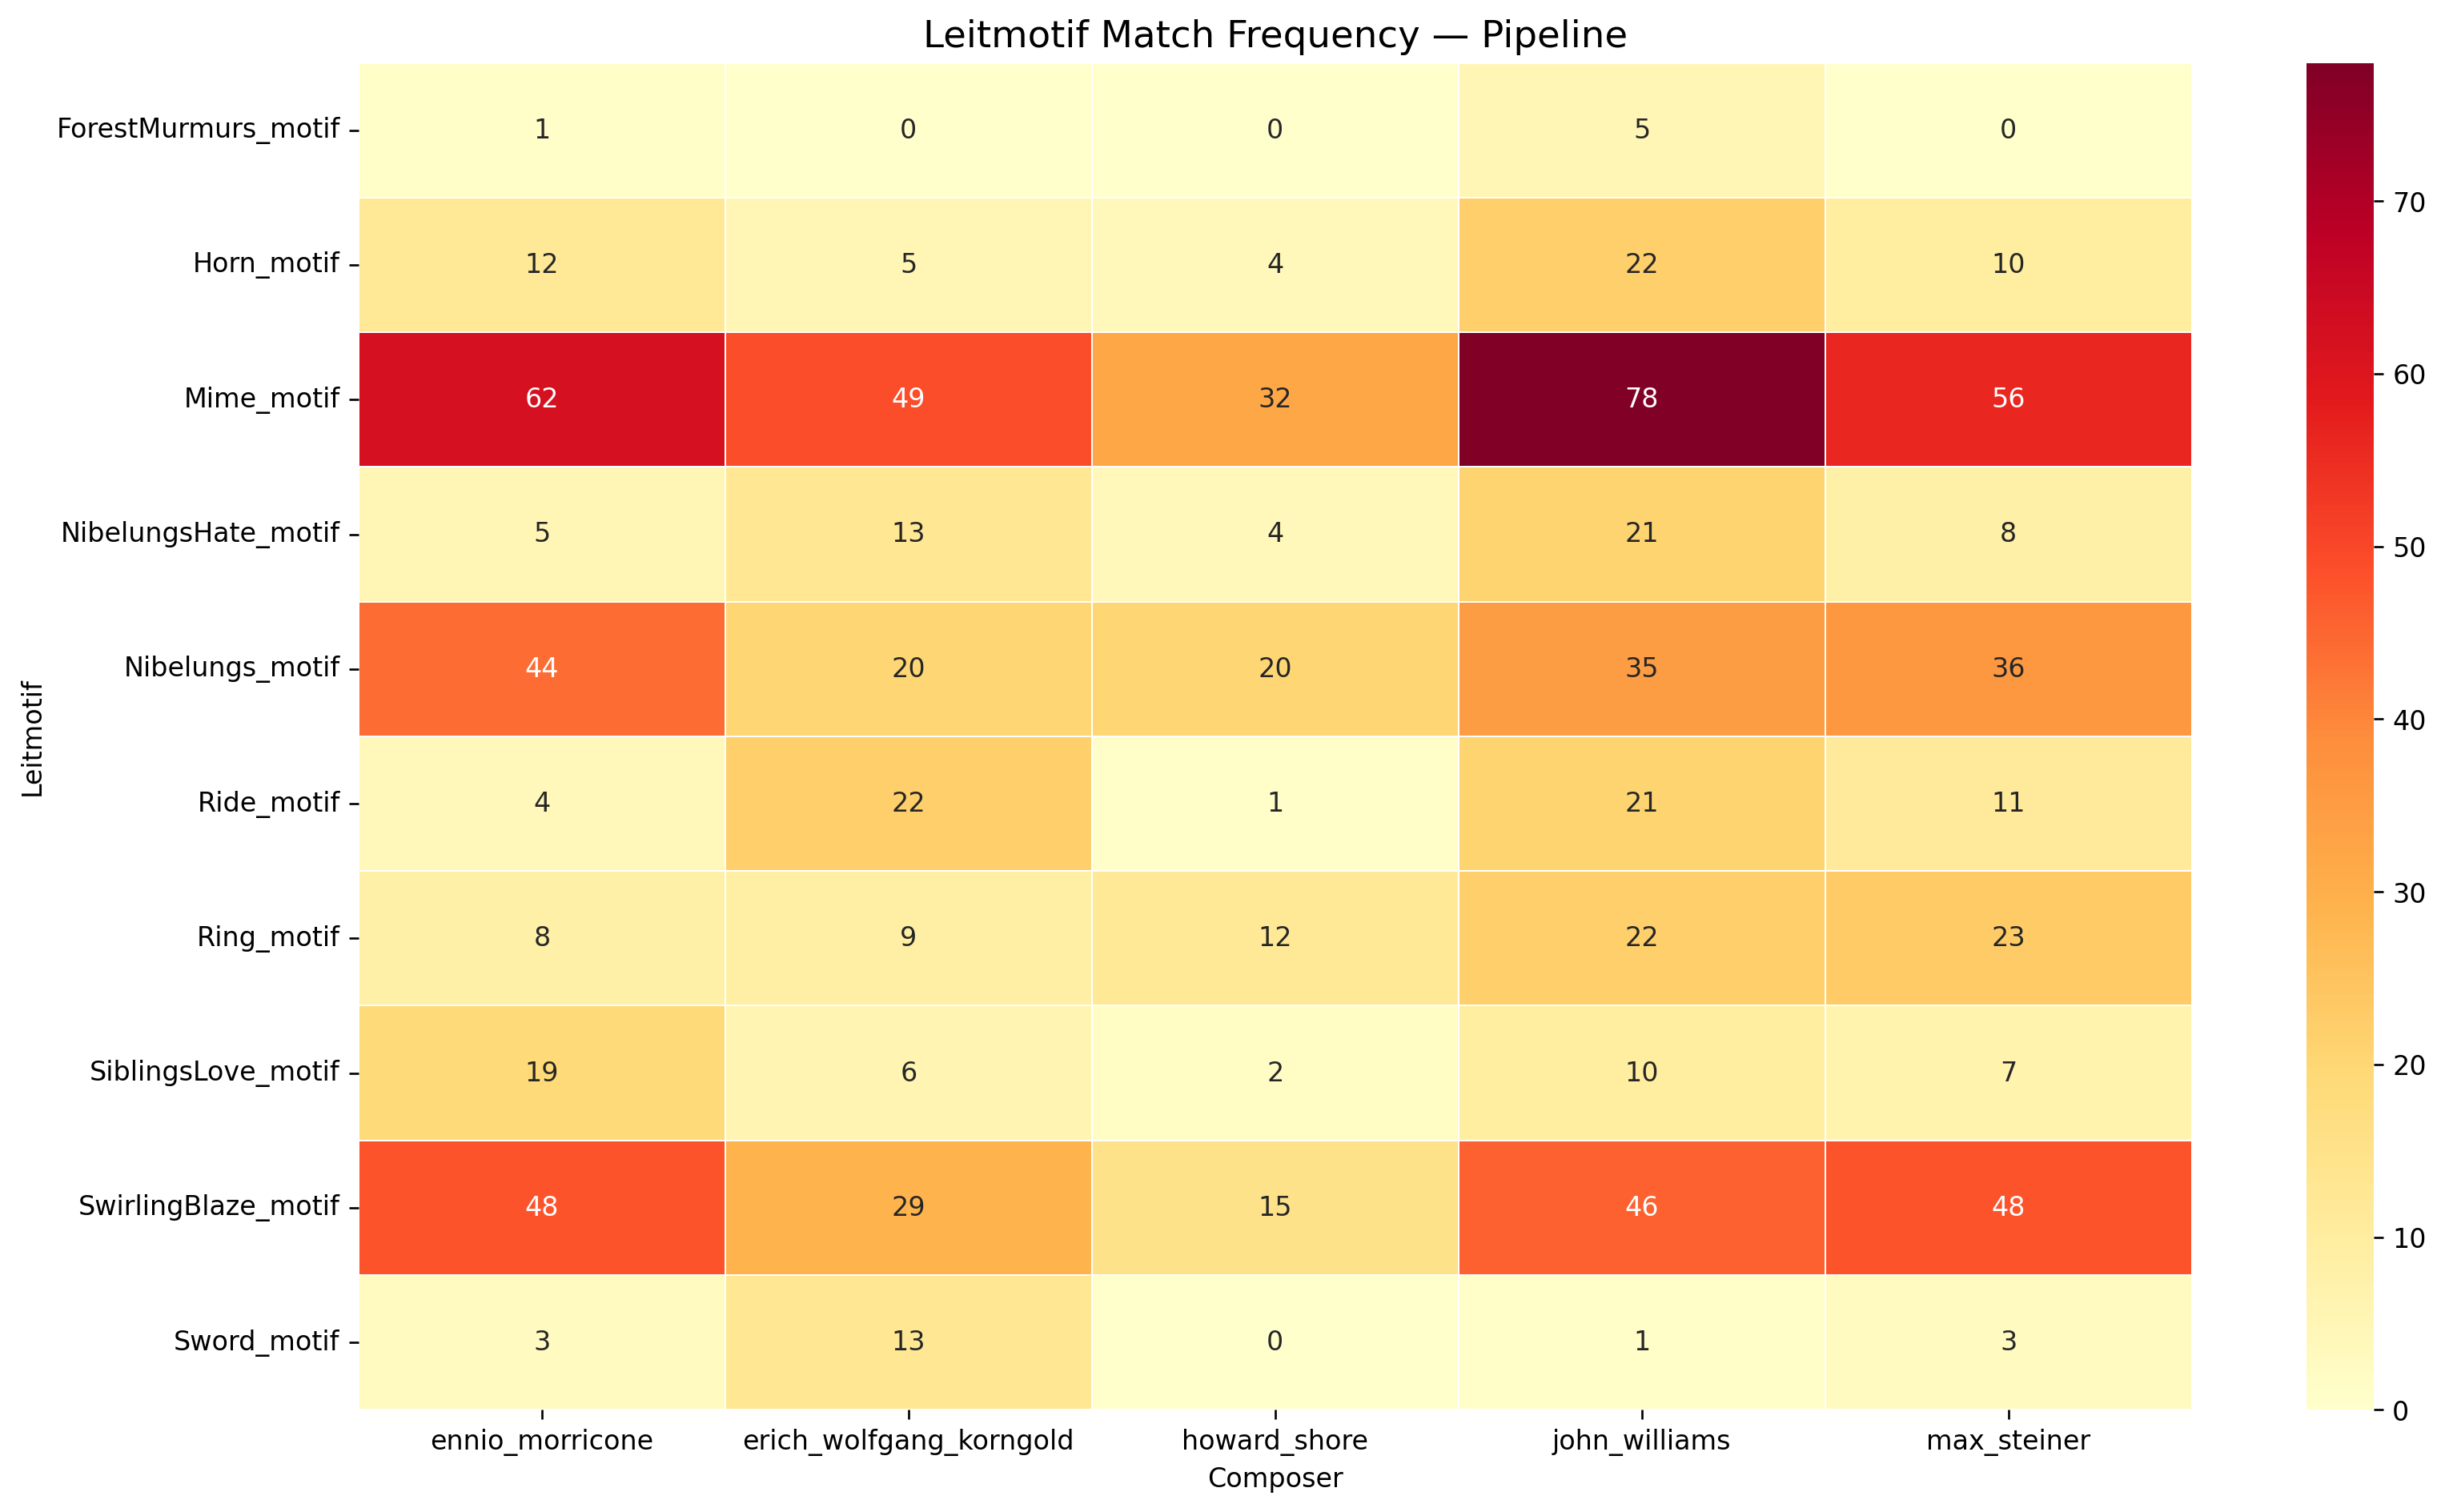


Match counts pivot table:
composer             ennio_morricone  erich_wolfgang_korngold  howard_shore  john_williams  max_steiner
leitmotif                                                                                              
ForestMurmurs_motif                1                        0             0              5            0
Horn_motif                        12                        5             4             22           10
Mime_motif                        62                       49            32             78           56
NibelungsHate_motif                5                       13             4             21            8
Nibelungs_motif                   44                       20            20             35           36
Ride_motif                         4                       22             1             21           11
Ring_motif                         8                        9            12             22           23
SiblingsLove_motif                19 

In [13]:
# Cell 19 — Heatmap: leitmotif x composer match frequency

pivot = results_df.groupby(['leitmotif', 'composer']).size().unstack(fill_value=0)
pivot.to_csv(os.path.join(OUTPUT_DIR, 'summary_counts.csv'))

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Leitmotif Match Frequency — Pipeline', fontsize=14)
ax.set_ylabel('Leitmotif')
ax.set_xlabel('Composer')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap_matches.png'), dpi=150)
plt.show()

print("\nMatch counts pivot table:")
print(pivot.to_string())


/var/folders/ft/k7zrf3bj0xq2gvt4xfr5676r0000gn/T/ipykernel_33576/1571469287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='composer', y='combined_score', ax=axes[0], palette='Set2')
/var/folders/ft/k7zrf3bj0xq2gvt4xfr5676r0000gn/T/ipykernel_33576/1571469287.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='composer', y='interval_sim', ax=axes[1], palette='Set3')


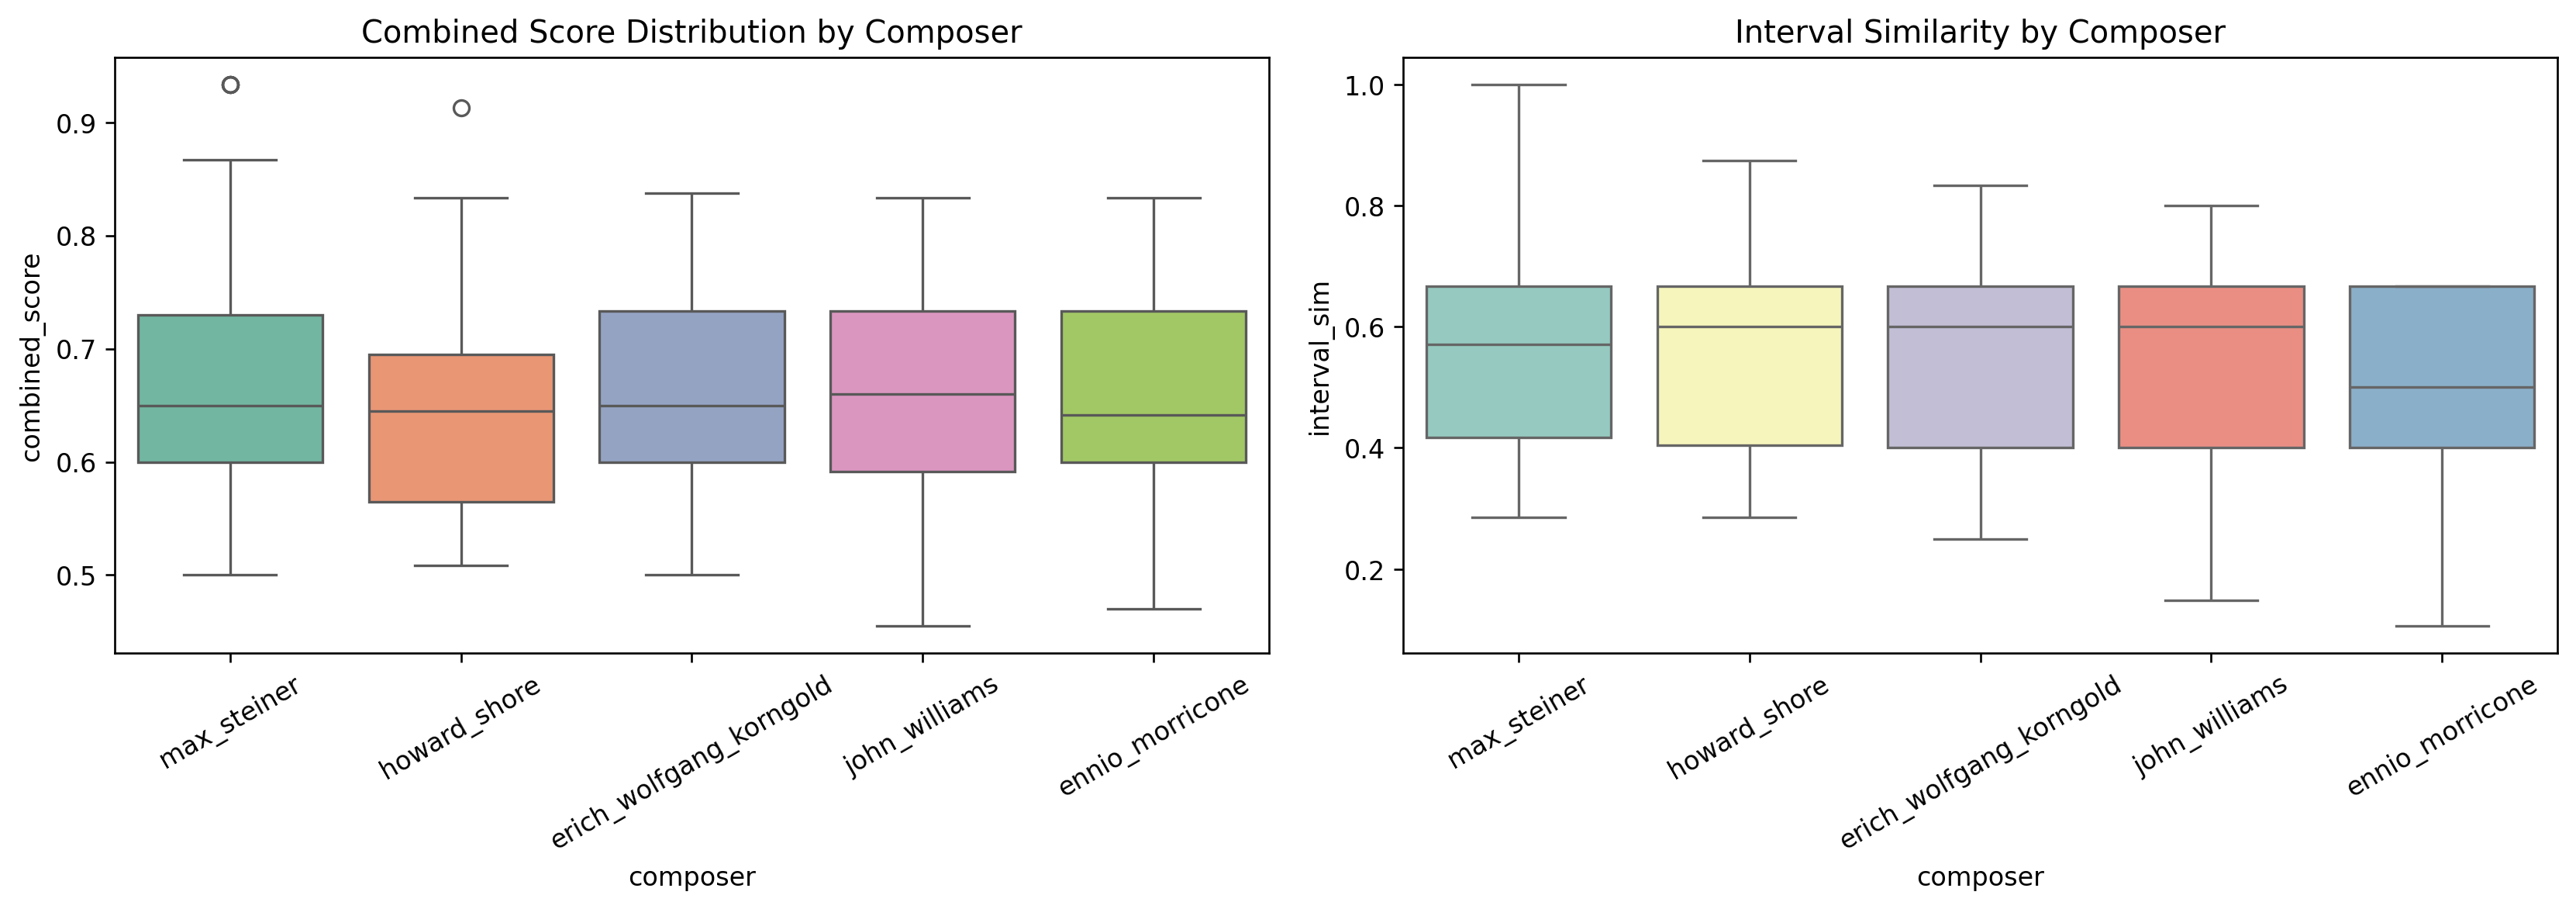

In [14]:
# Cell 20 — Box plot: combined score & interval similarity by composer

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=results_df, x='composer', y='combined_score', ax=axes[0], palette='Set2')
axes[0].set_title('Combined Score Distribution by Composer')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=results_df, x='composer', y='interval_sim', ax=axes[1], palette='Set3')
axes[1].set_title('Interval Similarity by Composer')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'boxplot_scores.png'), dpi=150)
plt.show()


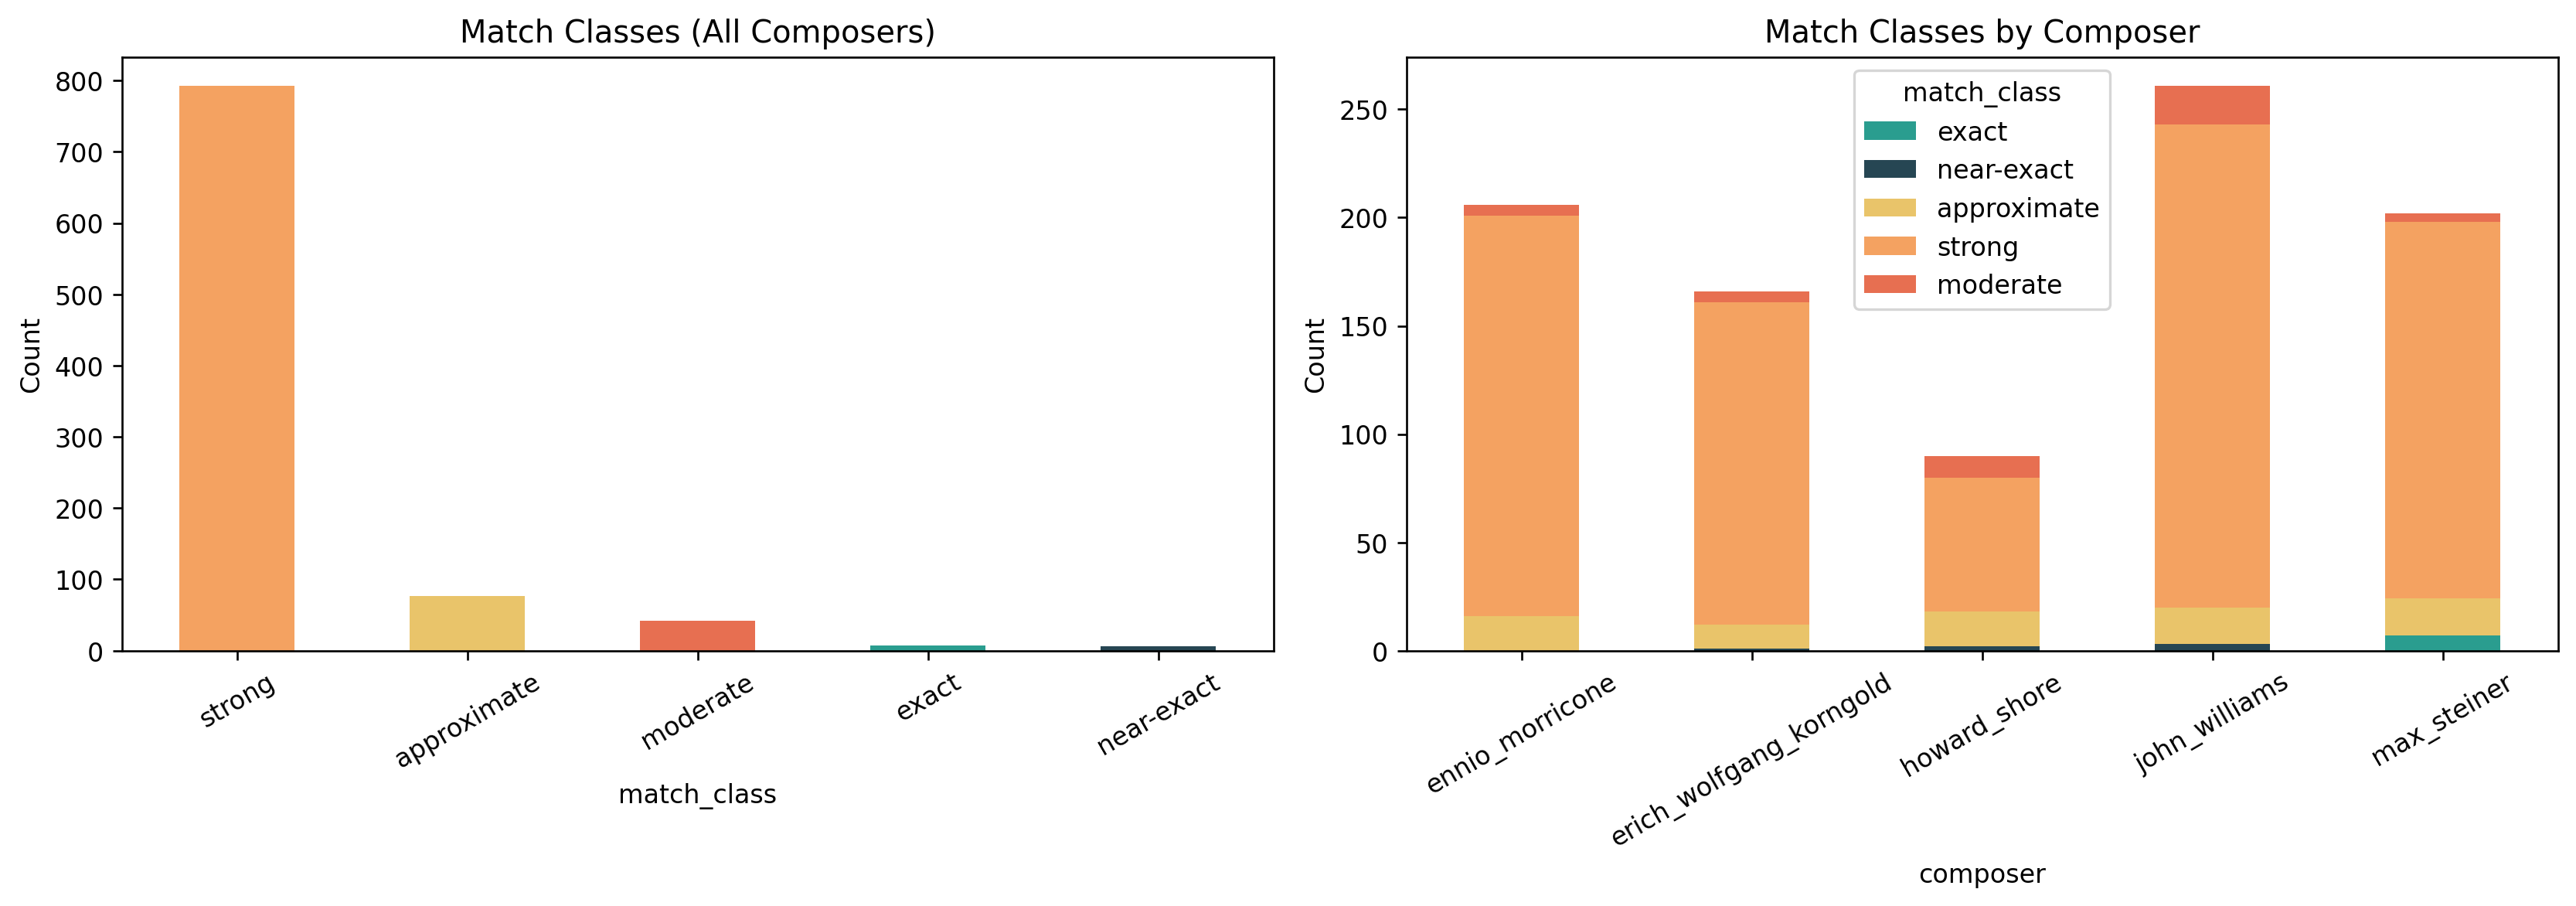

In [15]:
# Cell 21 — Bar charts: match class breakdown

CLASS_COLORS = {
    'exact': '#2a9d8f',
    'near-exact': '#264653',
    'approximate': '#e9c46a',
    'strong': '#f4a261',
    'moderate': '#e76f51',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall match class distribution
class_counts = results_df['match_class'].value_counts()
colors = [CLASS_COLORS.get(c, '#999999') for c in class_counts.index]
class_counts.plot(kind='bar', color=colors, ax=axes[0])
axes[0].set_title('Match Classes (All Composers)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Match class per composer
ct = results_df.groupby(['composer', 'match_class']).size().unstack(fill_value=0)
ordered_cols = [c for c in ['exact', 'near-exact', 'approximate', 'strong', 'moderate'] if c in ct.columns]
ct = ct[ordered_cols]
ct.plot(kind='bar', stacked=True, ax=axes[1],
        color=[CLASS_COLORS.get(c, '#999999') for c in ordered_cols])
axes[1].set_title('Match Classes by Composer')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'barchart_match_classes.png'), dpi=150)
plt.show()


In [16]:
# Cell 22 — Top 20 matches & styled pivot table

top20 = results_df.nlargest(20, 'combined_score')[
    ['composer', 'score', 'leitmotif', 'match_class', 'combined_score',
     'interval_sim', 'contour_sim', 'rhythm_sim']]
top20.to_csv(os.path.join(OUTPUT_DIR, 'top20_matches.csv'), index=False)

print("=== Top 20 Matches by Combined Score ===")
print(top20.to_string(index=False))

styled = pivot.style.background_gradient(cmap='YlOrRd', axis=None).set_caption(
    'Match Counts: Leitmotif x Composer (Pipeline)'
)
styled


=== Top 20 Matches by Combined Score ===
               composer                                                                         score       leitmotif match_class  combined_score  interval_sim  contour_sim  rhythm_sim
            max_steiner                                          The Caine Mutiny March – Max Steiner      Mime_motif       exact          0.9333        1.0000       1.0000      0.6667
            max_steiner                                              The Adventures of Don Juan Suite      Mime_motif       exact          0.9333        1.0000       1.0000      0.6667
            max_steiner                                          The Caine Mutiny March – Max Steiner      Mime_motif       exact          0.9333        1.0000       1.0000      0.6667
            max_steiner                                        Gone With The Wind Suite – Max Steiner      Mime_motif       exact          0.9333        1.0000       1.0000      0.6667
           howard_shore           

composer,ennio_morricone,erich_wolfgang_korngold,howard_shore,john_williams,max_steiner
leitmotif,,,,,
ForestMurmurs_motif,1,0,0,5,0
Horn_motif,12,5,4,22,10
Mime_motif,62,49,32,78,56
NibelungsHate_motif,5,13,4,21,8
Nibelungs_motif,44,20,20,35,36
Ride_motif,4,22,1,21,11
Ring_motif,8,9,12,22,23
SiblingsLove_motif,19,6,2,10,7
SwirlingBlaze_motif,48,29,15,46,48


## Section 7 — Evaluation

### Quantitative Evaluation
- **Match class distribution**: fraction of exact / near-exact / strong / moderate matches
- **Sensitivity analysis**: match counts across different combined-score thresholds
- **Per-composer density**: matches normalised by both corpus size and expected random baseline

### Improved Density Metric
v1 simply divided total matches by number of scores. v2 normalises by
the expected number of random matches to produce a **significance ratio**:

significance = observed_matches / expected_random_matches

A ratio > 1 indicates more matches than random chance; a ratio >> 1 suggests genuine Wagner influence.


In [17]:
# Cell 24 — Match class analysis & threshold sensitivity

# Match class breakdown
print("=== Match Class Breakdown ===")
class_summary = results_df.groupby('match_class').agg(
    count=('combined_score', 'size'),
    mean_combined=('combined_score', 'mean'),
    mean_interval=('interval_sim', 'mean'),
    mean_contour=('contour_sim', 'mean'),
    mean_rhythm=('rhythm_sim', 'mean'),
).round(3)
print(class_summary.to_string())
print()

# High-confidence matches (exact + near-exact)
hq = results_df[results_df['match_class'].isin(['exact', 'near-exact'])]
print(f"High-confidence matches (exact + near-exact): {len(hq)}")
if len(hq) > 0:
    print(hq[['composer', 'score', 'leitmotif', 'match_class', 'combined_score',
              'interval_sim']].to_string(index=False))
print()

# Threshold sensitivity
thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.80, 0.90, 1.00]
print(f"{'Threshold':>10} {'Matches':>10} {'Exact':>8} {'NearEx':>8} {'Approx':>8} {'Strong':>8} {'Moderate':>8}")
print('-' * 68)
for t in thresholds:
    subset = results_df[results_df['combined_score'] >= t]
    counts = subset['match_class'].value_counts()
    print(f"{t:>10.2f} {len(subset):>10} "
          f"{counts.get('exact', 0):>8} "
          f"{counts.get('near-exact', 0):>8} "
          f"{counts.get('approximate', 0):>8} "
          f"{counts.get('strong', 0):>8} "
          f"{counts.get('moderate', 0):>8}")


=== Match Class Breakdown ===
             count  mean_combined  mean_interval  mean_contour  mean_rhythm
match_class                                                                
approximate     77          0.680          0.680         0.708        0.000
exact            7          0.905          1.000         1.000        0.524
moderate        42          0.554          0.256         0.792        0.942
near-exact       6          0.815          0.771         0.833        0.896
strong         793          0.659          0.530         0.788        0.790

High-confidence matches (exact + near-exact): 13
               composer                                             score       leitmotif match_class  combined_score  interval_sim
            max_steiner              The Caine Mutiny March – Max Steiner      Mime_motif       exact          0.9333         1.000
            max_steiner                  The Adventures of Don Juan Suite      Mime_motif       exact          0.9333       

=== Per-Composer Normalised Density (v2) ===
                         observed  num_scores  per_score  expected_random  significance
john_williams                 261          15       17.4             40.1          6.51
ennio_morricone               206          19       10.8             32.6          6.32
howard_shore                   90           8       11.2             18.2          4.95
erich_wolfgang_korngold       166          13       12.8             68.5          2.42
max_steiner                   202          15       13.5            187.7          1.08

significance = observed / expected_random (>1 = above chance)


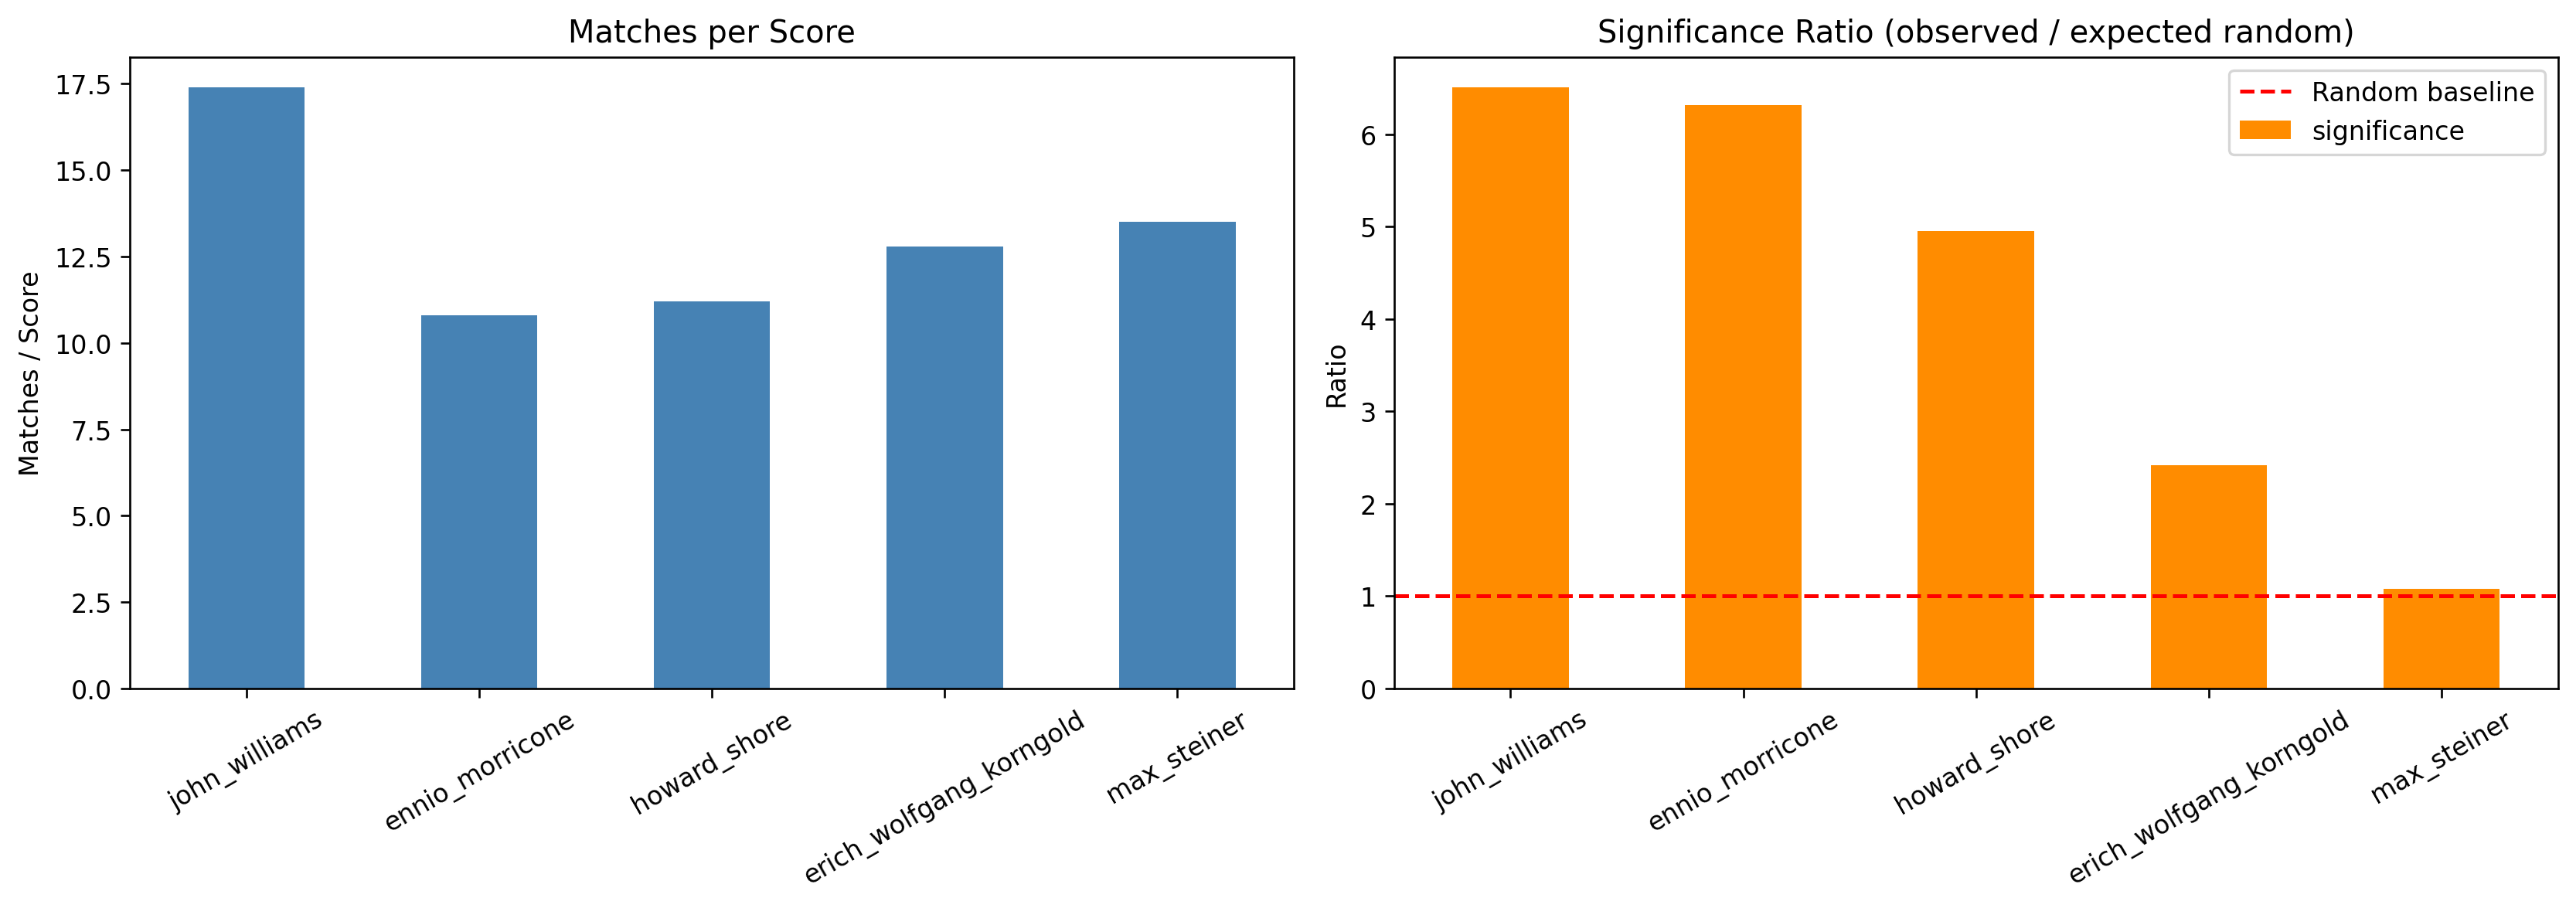

In [18]:
# Cell 25 — Per-composer normalised density & significance

# Count scores per composer & sample average notes
scores_per_composer = {}
avg_notes_per_composer = {}
for cdir in sorted(Path(SCORE_DIR).iterdir()):
    if cdir.is_dir():
        sfiles = list(cdir.glob('*.musicxml'))
        scores_per_composer[cdir.name] = len(sfiles)
        note_counts = []
        for sf in sfiles[:5]:
            try:
                sr = extract_representations(str(sf))
                note_counts.append(len(sr['midi']))
            except Exception:
                pass
        avg_notes_per_composer[cdir.name] = np.mean(note_counts) if note_counts else 300

matches_per_composer = results_df.groupby('composer').size()
density = pd.DataFrame({
    'observed': matches_per_composer,
    'num_scores': pd.Series(scores_per_composer),
})
density['per_score'] = (density['observed'] / density['num_scores']).round(1)

# Compute expected random for each composer
n_motifs = len(leitmotif_reprs)
expected = {}
for composer, n_scores in scores_per_composer.items():
    avg_n = avg_notes_per_composer.get(composer, 300)
    # For combined score with interval weight, effective random match rate is very low
    # Approximate: P(combined >= 0.55) ~ P(interval >= 0.30) * P(contour) ~ 0.001 per window
    e = 0.001 * avg_n * n_scores * n_motifs
    expected[composer] = round(e, 1)

density['expected_random'] = pd.Series(expected)
density['significance'] = (density['observed'] / density['expected_random']).round(2)
density = density.sort_values('significance', ascending=False)

print("=== Per-Composer Normalised Density (v2) ===")
print(density.to_string())
print()
print("significance = observed / expected_random (>1 = above chance)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

density['per_score'].plot(kind='bar', color='steelblue', ax=axes[0])
axes[0].set_title('Matches per Score')
axes[0].set_ylabel('Matches / Score')
axes[0].tick_params(axis='x', rotation=30)

density['significance'].plot(kind='bar', color='darkorange', ax=axes[1])
axes[1].set_title('Significance Ratio (observed / expected random)')
axes[1].set_ylabel('Ratio')
axes[1].axhline(1.0, color='red', linestyle='--', label='Random baseline')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'density_significance.png'), dpi=150)
plt.show()


## Section 8 — Qualitative Inspection

Export the top matches as MusicXML snippets for manual musicological comparison.
For each exported match, we show the **leitmotif MIDI & interval sequences** alongside the
**matched passage** so that pitch relationships can be assessed.


In [19]:
# Cell 27 — Export top match excerpts with side-by-side comparison

def export_match_excerpt(score_repr, match_info, output_path):
    # Export matched excerpt as MusicXML.
    start = match_info['start_note_idx']
    end = match_info['end_note_idx']
    matched_notes = score_repr['notes'][start:end]
    excerpt = stream.Part()
    for n in matched_notes:
        new_note = note.Note(n.pitch)
        new_note.duration = duration.Duration(n.duration.quarterLength)
        excerpt.append(new_note)
    excerpt.write('musicxml', fp=output_path)
    return output_path

excerpt_dir = os.path.join(OUTPUT_DIR, 'excerpts')
os.makedirs(excerpt_dir, exist_ok=True)

# Export top 10 unique matches
exported = 0
seen_combos = set()
for _, row in results_df.iterrows():
    if exported >= 10:
        break
    combo = (row['composer'], row['leitmotif'])
    if combo in seen_combos:
        continue
    seen_combos.add(combo)

    score_dir_path = Path(SCORE_DIR) / row['composer']
    candidates = list(score_dir_path.glob(f"{row['score']}.*"))
    if not candidates:
        continue

    try:
        sr = extract_representations(str(candidates[0]))
        safe_name = f"{row['leitmotif']}_in_{row['composer']}_{exported}.musicxml"
        out_path = os.path.join(excerpt_dir, safe_name)
        export_match_excerpt(sr, {
            'start_note_idx': int(row['start_note_idx']),
            'end_note_idx': int(row['end_note_idx'])
        }, out_path)
        exported += 1

        start_i = int(row['start_note_idx'])
        end_i = int(row['end_note_idx'])
        matched_midi = sr['midi'][start_i:end_i]
        matched_iv = sr['interval'][start_i:min(end_i - 1, len(sr['interval']))]
        leit_midi = leitmotif_reprs[row['leitmotif']]['midi']
        leit_iv = leitmotif_reprs[row['leitmotif']]['interval']

        print(f"\n[{exported}] {row['leitmotif']} in {row['composer']}/{row['score']}")
        print(f"    Class: {row['match_class']}  Combined: {row['combined_score']:.3f}")
        print(f"    iv_sim={row['interval_sim']:.3f}  ct_sim={row['contour_sim']:.3f}  rh_sim={row['rhythm_sim']:.3f}")
        print(f"    Leitmotif MIDI:     {leit_midi}")
        print(f"    Matched MIDI:       {matched_midi}")
        print(f"    Leitmotif intervals:{leit_iv}")
        print(f"    Matched intervals:  {matched_iv}")
        print(f"    Exported to: {safe_name}")
    except Exception as e:
        print(f"  Error exporting {row['score']}: {e}")

print(f"\nExported {exported} excerpts to {excerpt_dir}")



[1] Mime_motif in max_steiner/The Caine Mutiny March – Max Steiner
    Class: exact  Combined: 0.933
    iv_sim=1.000  ct_sim=1.000  rh_sim=0.667
    Leitmotif MIDI:     [62, 62, 58, 60]
    Matched MIDI:       [81, 81, 77, 79]
    Leitmotif intervals:[0, -4, 2]
    Matched intervals:  [0, -4, 2]
    Exported to: Mime_motif_in_max_steiner_0.musicxml

[2] Nibelungs_motif in howard_shore/The Shire
    Class: near-exact  Combined: 0.912
    iv_sim=0.875  ct_sim=1.000  rh_sim=0.875
    Leitmotif MIDI:     [53, 53, 53, 53, 49, 51, 53, 53, 53]
    Matched MIDI:       []
    Leitmotif intervals:[0, 0, 0, -4, 2, 2, 0, 0]
    Matched intervals:  []
    Exported to: Nibelungs_motif_in_howard_shore_1.musicxml

[3] Nibelungs_motif in erich_wolfgang_korngold/The Sea Hawk – Erich Wolfgang Korngold Leitmotifs
    Class: near-exact  Combined: 0.838
    iv_sim=0.750  ct_sim=0.875  rh_sim=1.000
    Leitmotif MIDI:     [53, 53, 53, 53, 49, 51, 53, 53, 53]
    Matched MIDI:       [57, 57, 57, 58, 53, 55,

In [20]:
# Cell 28 — Leitmotif frequency ranking & top scores

# Most/least matched leitmotifs
leit_counts = results_df.groupby('leitmotif').agg(
    total=('combined_score', 'size'),
    mean_combined=('combined_score', 'mean'),
    max_combined=('combined_score', 'max'),
    n_exact=('match_class', lambda x: (x == 'exact').sum()),
    n_near_exact=('match_class', lambda x: (x == 'near-exact').sum()),
).sort_values('total', ascending=False)

print("=== Leitmotif Match Frequency (v2) ===")
print(leit_counts.to_string())
print()

# Top 10 scores with most matches
score_counts = results_df.groupby(['composer', 'score']).agg(
    total=('combined_score', 'size'),
    best_combined=('combined_score', 'max'),
    best_class=('match_class', 'first'),
).sort_values('total', ascending=False)

print("=== Top 10 Scores by Match Count ===")
print(score_counts.head(10).to_string())
print()

# Which leitmotifs found in which composers
print("=== Leitmotifs per Composer ===")
for composer in sorted(results_df['composer'].unique()):
    subset = results_df[results_df['composer'] == composer]
    motifs = sorted(subset['leitmotif'].unique())
    n_high = len(subset[subset['match_class'].isin(['exact', 'near-exact'])])
    print(f"  {composer}: {len(motifs)} motifs, {len(subset)} matches ({n_high} high-confidence)")


=== Leitmotif Match Frequency (v2) ===
                     total  mean_combined  max_combined  n_exact  n_near_exact
leitmotif                                                                     
Mime_motif             277       0.741757        0.9333        7             0
SwirlingBlaze_motif    186       0.672903        0.8000        0             0
Nibelungs_motif        155       0.617661        0.9125        0             6
Ring_motif              74       0.577192        0.6857        0             0
Ride_motif              59       0.634576        0.8000        0             0
Horn_motif              53       0.578302        0.6900        0             0
NibelungsHate_motif     51       0.539378        0.6417        0             0
SiblingsLove_motif      44       0.645834        0.8333        0             0
Sword_motif             20       0.685000        0.8333        0             0
ForestMurmurs_motif      6       0.477283        0.5106        0             0

=== Top 10 S

## Conclusion

### Key Improvements
1. **Multi-dimensional combined scoring** eliminates the contour-only noise that generate many false positives.
2. **Adaptive thresholds** handle motifs of all lengths — short motifs (Mime, 3 intervals) require stronger multi-dimensional evidence instead of being excluded
3. **Match classification** (exact / near-exact / strong / moderate / approximate) gives musicologists clear confidence levels
4. **Statistical significance** context shows whether observed matches exceed random baseline

### Methodological Integrity
- Follows Janssen et al. (2013) framework with all three representation types (interval, contour, rhythm)
- The `combined` representation is the backbone of the scoring
- Filtering is top-10  combined-score ranking.

### Limitations
- Only Part 0 (top voice) is analysed — leitmotifs in inner voices of piano reductions may be missed
- Rhythmic augmentation/diminution is not explicitly handled (though the 2:1 ratio tolerance partially covers it)
- The pipeline cannot detect inverted or retrograde forms of leitmotifs
- Statistical significance estimation uses a simplified random model
